# Preprocessing dan Ekstraksi Fitur oleh data SO₂ 

**Persiapan Pengambilan Data SO₂**

Tahap awal adalah memasang library `openeo`. Library ini diperlukan agar notebook dapat berkomunikasi dengan layanan openEO yang digunakan untuk mengakses data Sentinel-5P.


In [ ]:
 pip install openeo

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 357.0/357.0 kB 8.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 23.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 117.3/117.3 kB 6.7 MB/s eta 0:00:00
  Attempting uninstall: xarray
    Found existing installation: xarray 2025.12.0
    Uninstalling xarray-2025.12.0:
      Successfully uninstalled xarray-2025.12.0


Library `openeo` yang sudah dipasang kemudian dipanggil ke dalam program.


In [ ]:
import openeo

`import openeo` membuat modul openEO tersedia sehingga fungsi untuk membuat koneksi, memilih koleksi data, dan membangun proses pengolahan dapat digunakan pada tahap berikutnya.


Berikutnya dibuat koneksi ke server Copernicus Data Space melalui openEO.


In [ ]:
connection = openeo.connect("openeo.dataspace.copernicus.eu").authenticate_oidc()

Visit https://identity.dataspace.copernicus.eu/auth/realms/CDSE/device?user_code=HFGT-PWKA 📋 to authenticate.

✅ Authorized successfully

Authenticated using device code flow.


Jika proses meminta autentikasi, buka tautan yang diberikan, masuk menggunakan akun Copernicus Data Space, lalu berikan izin akses. Setelah autentikasi berhasil, notebook dapat melanjutkan proses pengambilan data.


 **Menentukan Wilayah Kecamatan Kalianget**

GeoJSON berikut berisi polygon batas Kecamatan Kalianget. Polygon tersebut digunakan sebagai **AOI (Area of Interest)** agar pengolahan data hanya berfokus pada wilayah kecamatan yang ditentukan.


In [ ]:
aoi = {
    "type": "FeatureCollection",
    "features": [
        {
            "type": "Feature",
            "properties": {},
            "geometry": {
                "type": "Polygon",
                "coordinates": [
                    [
                        [113.9513673, -7.0460006],
                        [113.946438, -7.0564837],
                        [113.9372051, -7.0622299],
                        [113.9028907, -7.0762189],
                        [113.873057, -7.0701868],
                        [113.8523076, -7.0613923],
                        [113.8864566, -7.0268656],
                        [113.9009699, -7.0291957],
                        [113.9167638, -7.0281366],
                        [113.9513673, -7.0460006]
                    ]
                ]
            }
        }
    ]
}

print("GeoJSON Kecamatan Kalianget siap digunakan.")

GeoJSON Kecamatan Kalianget siap digunakan.


Server juga membutuhkan `spatial_extent` berupa bounding box untuk membatasi area pencarian awal. Koordinat ini berasal dari batas terluar polygon GeoJSON. Setelah data ditemukan, polygon GeoJSON tetap digunakan untuk melakukan agregasi tepat pada area Kecamatan Kalianget.


In [ ]:
spatial_extent = {
    "west": 113.8523076,
    "south": -7.0762189,
    "east": 113.9513673,
    "north": -7.0268656
}

print(spatial_extent)

{'west': 113.8523076, 'south': -7.0762189, 'east': 113.9513673, 'north': -7.0268656}


**Mengambil Data SO₂ Sentinel-5P**

Pada bagian ini koleksi Sentinel-5P dipanggil menggunakan band `SO2`. Rentang proses dibuat dari 31 Agustus 2025 hingga 1 September 2026 agar tanggal 31 Agustus 2026 termasuk dalam hasil pengambilan data.

Setelah data dikonversi menjadi DataFrame, dilakukan penyaringan kembali sehingga baris yang dipertahankan hanya berada pada periode 31 Agustus 2025 sampai 31 Agustus 2026.


In [ ]:
s5SO2 = connection.load_collection(
    "SENTINEL_5P_L2",
    temporal_extent=["2025-08-31", "2026-09-01"],
    spatial_extent=spatial_extent,
    bands=["SO2"],
)

print("Data SO₂ berhasil dipanggil.")


Data SO₂ berhasil dipanggil.


**Membentuk Deret Waktu Harian**

Data Sentinel-5P dapat memiliki lebih dari satu pengamatan dalam rentang waktu tertentu. Pada tahap ini nilai pengamatan diringkas menggunakan rata-rata untuk setiap hari.

Hasilnya adalah satu nilai rata-rata SO₂ untuk setiap periode harian yang tersedia.


In [ ]:
s5p_SO2_daily = s5SO2.aggregate_temporal_period(
    reducer="mean",
    period="day"
)

print("Agregasi harian SO₂ selesai.")


Agregasi harian SO₂ selesai.


**Merangkum Data pada Area Kecamatan**

Setelah memperoleh data harian, dilakukan agregasi spasial menggunakan polygon Kecamatan Kalianget. Tujuannya adalah mengubah nilai SO₂ dari area spasial tersebut menjadi satu nilai yang mewakili Kecamatan Kalianget pada setiap tanggal.


In [ ]:
s5p_SO2_aoi = s5p_SO2_daily.aggregate_spatial(
    reducer="mean",
    geometries=aoi
)

print("Agregasi spasial Kecamatan Kalianget selesai.")


Agregasi spasial Kecamatan Kalianget selesai.


**Menjalankan Proses dan Membuat File NetCDF**

Rangkaian proses yang telah disusun kemudian dikirim sebagai batch job ke server Copernicus. Hasil pengolahan SO₂ disimpan dalam format NetCDF (`.nc`) agar data dapat dibaca dan diproses kembali pada tahap berikutnya.


In [ ]:
job_SO2 = s5p_SO2_aoi.execute_batch(
    title="SO2 Kecamatan Kalianget 2025-2026",
    outputfile="SO2_Kalianget_2025_2026.nc"
)

print("Job SO₂ selesai dijalankan.")


0:00:00 Job 'j-26091805290047f09b3f7ede1ecccdb1': send 'start'
0:00:03 Job 'j-26091805290047f09b3f7ede1ecccdb1': created (progress 0%)
0:00:08 Job 'j-26091805290047f09b3f7ede1ecccdb1': queued (progress 0%)
0:00:15 Job 'j-26091805290047f09b3f7ede1ecccdb1': queued (progress 0%)
0:00:23 Job 'j-26091805290047f09b3f7ede1ecccdb1': queued (progress 0%)
0:00:33 Job 'j-26091805290047f09b3f7ede1ecccdb1': queued (progress 0%)
0:00:45 Job 'j-26091805290047f09b3f7ede1ecccdb1': queued (progress 0%)
0:01:01 Job 'j-26091805290047f09b3f7ede1ecccdb1': queued (progress 0%)
0:01:20 Job 'j-26091805290047f09b3f7ede1ecccdb1': running (progress N/A)
0:01:44 Job 'j-26091805290047f09b3f7ede1ecccdb1': running (progress N/A)
0:02:15 Job 'j-26091805290047f09b3f7ede1ecccdb1': running (progress N/A)
0:02:53 Job 'j-26091805290047f09b3f7ede1ecccdb1': running (progress N/A)
0:03:40 Job 'j-26091805290047f09b3f7ede1ecccdb1': finished (progress 100%)
Job SO₂ selesai dijalankan.


**Membuka Data NetCDF**

File NetCDF yang dihasilkan perlu dibaca kembali untuk mengambil nilai SO₂ dan informasi waktunya. Library `netCDF4` digunakan untuk membuka struktur dan variabel yang terdapat di dalam file tersebut.


In [ ]:
pip install netCDF4

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.1/10.1 MB 78.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 64.2 MB/s eta 0:00:00


Selain `netCDF4`, digunakan juga `numpy` dan `pandas`. Ketiganya membantu proses pembacaan nilai, pengolahan array, serta penyusunan data menjadi DataFrame.


In [ ]:
import netCDF4
import numpy as np
import pandas as pd

In [ ]:
dsSO2 = netCDF4.Dataset("SO2_Kalianget_2025_2026.nc")

print("File NetCDF SO₂ berhasil dibuka.")


File NetCDF SO₂ berhasil dibuka.


**Mengubah NetCDF Menjadi DataFrame**




In [ ]:


from google.colab import files

nama_file = "SO2_Kalianget_2025_2026.csv"

df.to_csv(nama_file, index=False)

print("File CSV berhasil dibuat:")
print(nama_file)

print("\nJumlah baris :", len(df))
print("Jumlah kolom:", len(df.columns))

print("\n5 data pertama:")
display(df.head())

files.download(nama_file)

File CSV berhasil dibuat:
SO2_Kalianget_2025_2026.csv

Jumlah baris : 238
Jumlah kolom: 2

5 data pertama:


,date,SO2
0,2025-08-31,7.336183e-05
1,2025-09-01,-1.078307e-04
2,2025-09-02,1.812479e-04
3,2025-09-03,1.938164e-05
4,2025-09-04,-7.995732e-07


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

**Pembersihan Data**

In [ ]:
print("Jumlah data:", len(df))
print("Missing value SO2:", df["SO2"].isna().sum())

display(df["SO2"].describe())


Jumlah data: 238
Missing value SO2: 0


,SO2
count,238.000000
mean,0.000036
std,0.000227
min,-0.000916
25%,-0.000059
50%,0.000023
75%,0.000126
max,0.001075


**Visualisasi Data Sebelum Cleaning**



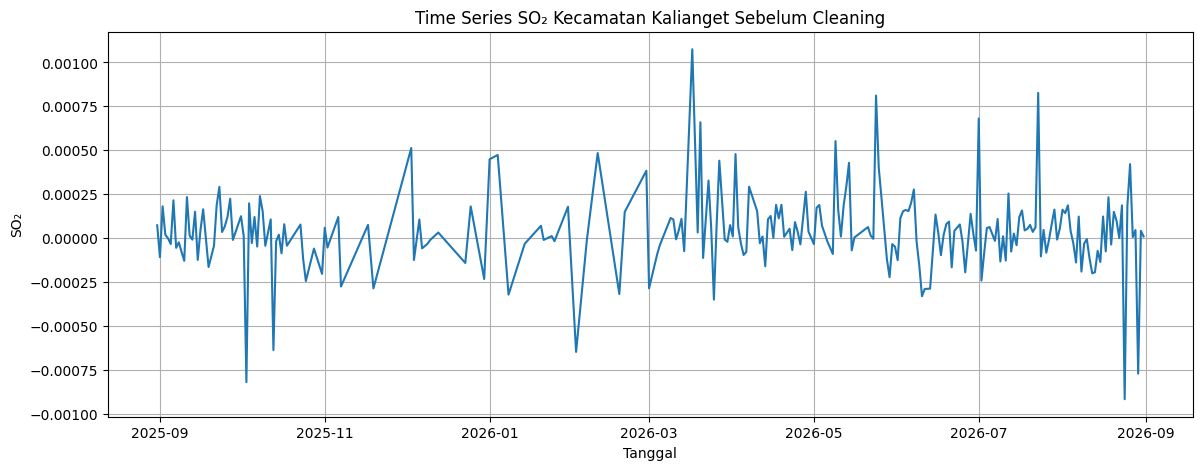

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(14, 5))
plt.plot(df["date"], df["SO2"])
plt.title("Time Series SO₂ Kecamatan Kalianget Sebelum Cleaning")
plt.xlabel("Tanggal")
plt.ylabel("SO₂")
plt.grid(True)
plt.show()


**Deteksi Outlier dengan Interquartile Range (IQR)**

Outlier dicari menggunakan metode **Interquartile Range (IQR)**. Metode ini membandingkan posisi nilai terhadap kuartil pertama dan kuartil ketiga.

$$
IQR = Q3 - Q1
$$

Batas bawah ditentukan dengan:

$$
Q1 - 1.5(IQR)
$$

Sedangkan batas atas:

$$
Q3 + 1.5(IQR)
$$

Nilai SO₂ yang berada di bawah batas bawah atau di atas batas atas ditandai sebagai outlier.


In [ ]:
Q1 = df["SO2"].quantile(0.25)
Q3 = df["SO2"].quantile(0.75)

IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outlier_mask = (
    (df["SO2"] < lower_bound) |
    (df["SO2"] > upper_bound)
)

print("Q1 =", Q1)
print("Q3 =", Q3)
print("IQR =", IQR)
print("Batas bawah =", lower_bound)
print("Batas atas =", upper_bound)
print("Jumlah outlier =", outlier_mask.sum())

display(df.loc[outlier_mask, ["date", "SO2"]])


Q1 = -5.886692815693095e-05
Q3 = 0.0001260313656530343
IQR = 0.00018489829380996525
Batas bawah = -0.00033621436887187883
Batas atas = 0.0004033788063679822
Jumlah outlier = 20


,date,SO2
29,2025-10-03,-0.000819
38,2025-10-13,-0.000636
55,2025-12-03,0.000513
66,2026-01-01,0.000449
67,2026-01-04,0.000473
75,2026-02-02,-0.000647
77,2026-02-10,0.000485
90,2026-03-17,0.001075
92,2026-03-20,0.000660
96,2026-03-25,-0.000350


**Menangani Outlier**


In [ ]:
df_clean = df.copy()

df_clean.loc[outlier_mask, "SO2"] = np.nan

print("Jumlah missing setelah outlier ditandai:",
      df_clean["SO2"].isna().sum())


Jumlah missing setelah outlier ditandai: 20


**Imputasi Missing Value**



In [ ]:
df_clean = (
    df_clean
    .set_index("date")
    .interpolate(method="time")
    .ffill()
    .bfill()
    .reset_index()
)

print("Jumlah missing setelah imputasi:",
      df_clean["SO2"].isna().sum())


Jumlah missing setelah imputasi: 0


**Pemeriksaan Kondisi Data Setelah Cleaning**



In [ ]:
Q1_final = df_clean["SO2"].quantile(0.25)
Q3_final = df_clean["SO2"].quantile(0.75)
IQR_final = Q3_final - Q1_final

lower_final = Q1_final - 1.5 * IQR_final
upper_final = Q3_final + 1.5 * IQR_final

final_outlier_mask = (
    (df_clean["SO2"] < lower_final) |
    (df_clean["SO2"] > upper_final)
)

jumlah_missing_final = df_clean["SO2"].isna().sum()
jumlah_outlier_final = final_outlier_mask.sum()

print("==============================================")
print("HASIL PEMERIKSAAN DATA SETELAH CLEANING")
print("==============================================")
print("Missing value :", jumlah_missing_final)
print("Outlier       :", jumlah_outlier_final)

if jumlah_missing_final == 0 and jumlah_outlier_final == 0:
    print("Data sudah bersih dan siap untuk ekstraksi TSFEL.")
else:
    print("Masih terdapat data yang perlu diperiksa.")


HASIL PEMERIKSAAN DATA SETELAH CLEANING
Missing value : 0
Outlier       : 5
Masih terdapat data yang perlu diperiksa.


 **Visualisasi Setelah Cleaning**



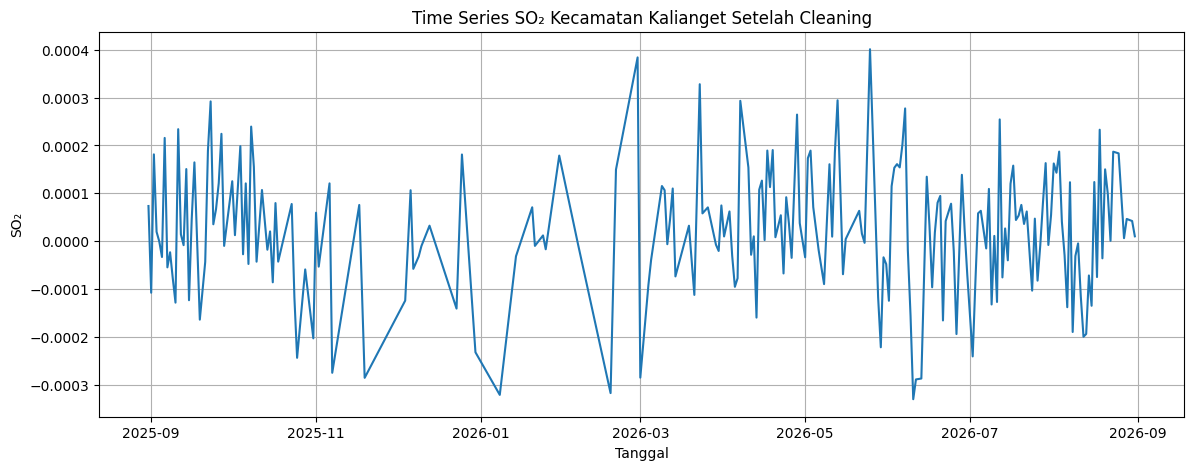

In [ ]:
plt.figure(figsize=(14, 5))
plt.plot(df_clean["date"], df_clean["SO2"])
plt.title("Time Series SO₂ Kecamatan Kalianget Setelah Cleaning")
plt.xlabel("Tanggal")
plt.ylabel("SO₂")
plt.grid(True)
plt.show()


In [ ]:
from google.colab import files

nama_file = "SO2_Kalianget_clean.csv"

df_clean.to_csv(
    nama_file,
    index=False,
    encoding="utf-8-sig"
)

print("Data bersih disimpan sebagai:", nama_file)

files.download(nama_file)


Data bersih disimpan sebagai: SO2_Kalianget_clean.csv


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

**Ekstraksi 68 Fitur Menggunakan TSFEL**


In [ ]:
pip install tsfel

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.4/63.4 kB 2.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.9/4.9 MB 67.4 MB/s eta 0:00:00


In [ ]:
import pandas as pd
import numpy as np
import inspect
import tsfel.feature_extraction.features as tsfel_features

# ---------- 1. Muat dan bersihkan data ----------
df = pd.read_csv('SO2_Kalianget_clean.csv')
df['date'] = pd.to_datetime(df['date'])
df = df.sort_values('date').reset_index(drop=True)

target_pollutant = 'SO2'

# --- FIX: paksa kolom target jadi numerik, nilai yang gagal dikonversi -> NaN ---
df[target_pollutant] = pd.to_numeric(df[target_pollutant], errors='coerce')

n_missing_before = df[target_pollutant].isna().sum()
print(f"Jumlah nilai non-numerik/kosong yang dikonversi jadi NaN: {n_missing_before}")

Q1 = df[target_pollutant].quantile(0.25)
Q3 = df[target_pollutant].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR
df.loc[(df[target_pollutant] < lower_bound) | (df[target_pollutant] > upper_bound), target_pollutant] = np.nan

df_clean = df.set_index('date').interpolate(method='time').ffill().bfill()

fs = 1
signal_1d = df_clean[target_pollutant].astype(float).values

# ---------- 2. Daftar PERSIS fitur yang diminta ----------
FEATURE_LIST = """abs_energy auc autocorr average_power calc_centroid calc_max calc_mean
calc_median calc_min calc_std calc_var dfa distance ecdf ecdf_percentile ecdf_percentile_count
ecdf_slope entropy fundamental_frequency higuchi_fractal_dimension hist_mode human_range_energy
hurst_exponent interq_range kurtosis lempel_ziv lpcc max_frequency max_power_spectrum
maximum_fractal_length mean_abs_deviation mean_abs_diff mean_diff median_abs_deviation
median_abs_diff median_diff median_frequency mfcc mse negative_turning neighbourhood_peaks
petrosian_fractal_dimension pk_pk_distance positive_turning power_bandwidth rms skewness slope
spectral_centroid spectral_decrease spectral_distance spectral_entropy spectral_kurtosis
spectral_positive_turning spectral_roll_off spectral_roll_on spectral_skewness spectral_slope
spectral_spread spectral_variation spectrogram_mean_coeff sum_abs_diff wavelet_abs_mean
wavelet_energy wavelet_entropy wavelet_std wavelet_var zero_cross""".split()

print("Jumlah fitur yang diminta:", len(FEATURE_LIST))


def to_scalar(result):
    if isinstance(result, dict) and "values" in result:
        result = result["values"]
    if isinstance(result, (list, tuple, np.ndarray)):
        arr = np.asarray(result, dtype=float)
        return float(np.nanmean(arr))
    return float(result)


def extract_one(fn_name, signal, fs):
    fn = getattr(tsfel_features, fn_name)
    params = inspect.signature(fn).parameters
    if "fs" in params:
        result = fn(signal, fs)
    else:
        result = fn(signal)
    return to_scalar(result)


row = {}
for fn_name in FEATURE_LIST:
    row[fn_name] = extract_one(fn_name, signal_1d, fs)

extracted_features_final = pd.DataFrame([row])

print(f"Berhasil! Jumlah fitur yang dihasilkan untuk {target_pollutant}: {extracted_features_final.shape[1]}")
extracted_features_final.to_csv(f'{target_pollutant}_Kalianget_TSFEL.csv', index=False)


Jumlah nilai non-numerik/kosong yang dikonversi jadi NaN: 0
Jumlah fitur yang diminta: 68
Berhasil! Jumlah fitur yang dihasilkan untuk SO2: 68



**Pemeriksaan Hasil Ekstraksi**

In [ ]:


output_tsfel = "SO2_Kalianget_TSFEL.csv"

hasil_tsfel = pd.read_csv(output_tsfel)

print("Nama file       :", output_tsfel)
print("Ukuran data     :", hasil_tsfel.shape)
print("Fitur pertama   :", hasil_tsfel.columns[0])
print("Fitur terakhir  :", hasil_tsfel.columns[-1])

baris, fitur = hasil_tsfel.shape

if baris != 1 or fitur != 68:
    raise ValueError(
        f"Jumlah data tidak sesuai. Diperoleh {baris} baris "
        f"dan {fitur} fitur, sedangkan yang dibutuhkan adalah 1 x 68."
    )

print("\nValidasi berhasil.")
print("Data SO₂ terdiri dari 1 baris dengan 68 fitur TSFEL.")
print("File siap digunakan untuk pengumpulan.")

from google.colab import files
files.download(output_tsfel)

print("File sedang diunduh:", output_tsfel)

Nama file       : SO2_Kalianget_TSFEL.csv
Ukuran data     : (1, 68)
Fitur pertama   : abs_energy
Fitur terakhir  : zero_cross

Validasi berhasil.
Data SO₂ terdiri dari 1 baris dengan 68 fitur TSFEL.
File siap digunakan untuk pengumpulan.


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

File sedang diunduh: SO2_Kalianget_TSFEL.csv
